# Satellite Data Preprocessing

Input : `data/raw/DataAOD/Hanoi/all_stations_satellite_daily.csv`  
Output: `data/interim/satellite/`

**Steps:**
1. Load & explore missing rates
2. Select representative features (drop redundant percentile columns)
3. Fill S5P gaps (≤7-day interpolation, median fallback)
4. Fill S2 gaps (≤15-day interpolation, median fallback) — S2 revisit ~5 days
5. Add `*_was_missing` flags
6. Save cleaned daily satellite CSV
7. Train / validation / test split (70 / 15 / 15, chronological)
8. StandardScaler fitted on train only → save scaler + scaled arrays

## 1. Imports & Configuration

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path("D:/Bussiness_plan/Multimodal_PM25")
INPUT_CSV    = PROJECT_ROOT / "data/raw/DataAOD/Hanoi/all_stations_satellite_daily.csv"
OUTPUT_DIR   = PROJECT_ROOT / "data/interim/satellite"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

# Interpolation limits
S5P_INTERP_LIMIT = 7   # S5P: 1 pass/day → up to 7 missing days ok
S2_INTERP_LIMIT  = 15  # S2: revisit ~5 days → allow 15-day gap

# Representative features (mean + valid_pixels; drop min/max/std/median to reduce redundancy)
S5P_FEATURES = ['no2_mean','co_mean','so2_mean','aer_ai_340_380_mean',
                'no2_valid_pixels','co_valid_pixels','so2_valid_pixels','aer_ai_340_380_valid_pixels']
S2_FEATURES  = ['ndvi_mean','ndbi_mean','ndwi_mean','s2_valid_pixels']
META_COLS    = ['location_id','location_name','latitude','longitude','date']

print(f"Output: {OUTPUT_DIR}")


Output: D:\Bussiness_plan\Multimodal_PM25\data\interim\satellite


## 2. Load & Explore

In [2]:
df_raw = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw = df_raw.dropna(subset=["date"]).reset_index(drop=True)

print(f"Shape : {df_raw.shape}")
print(f"Range : {df_raw['date'].min().date()}  ->  {df_raw['date'].max().date()}")
display(df_raw.groupby('location_id').agg(
    name=('location_name','first'), rows=('date','count'),
    start=('date','min'), end=('date','max')))

# Missing rates for selected features
feat_cols = S5P_FEATURES + S2_FEATURES
feat_cols = [c for c in feat_cols if c in df_raw.columns]
miss = (df_raw[feat_cols].isnull().mean()*100).round(1).rename('missing_%')
print("\nMissing rates:")
display(miss.to_frame())


Shape : (5028, 45)
Range : 2024-01-29  ->  2026-05-15


,name,rows,start,end
location_id,,,,
2161292,"Số 46, phố Lưu Quang Vũ",838,2024-01-29,2026-05-15
2161306,Minh Khai - Bắc Từ Liêm,838,2024-01-29,2026-05-15
4946811,556 Nguyễn Văn Cừ,838,2024-01-29,2026-05-15
4946812,Công viên Nhân Chính - Khuất Duy Tiến,838,2024-01-29,2026-05-15
4946813,Số 1 đường Giải Phóng - phường Bạch Mai - ĐHBK,838,2024-01-29,2026-05-15
6123215,OceanPark,838,2024-01-29,2026-05-15



Missing rates:


,missing_%
no2_mean,43.6
co_mean,22.2
so2_mean,30.7
aer_ai_340_380_mean,0.1
no2_valid_pixels,0.0
co_valid_pixels,0.0
so2_valid_pixels,0.0
aer_ai_340_380_valid_pixels,0.0
ndvi_mean,78.2
ndbi_mean,78.2


## 3. Fill Gaps Per Station

In [3]:
S5P_COLS = [c for c in S5P_FEATURES if 'valid_pixels' not in c and c in df_raw.columns]
S2_COLS  = [c for c in S2_FEATURES  if 'valid_pixels' not in c and c in df_raw.columns]
PIX_COLS = [c for c in feat_cols if 'valid_pixels' in c]

parts = []
for loc_id, grp in df_raw.groupby('location_id', sort=False):
    grp = grp.sort_values('date').set_index('date')
    full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq='D')
    grp = grp.reindex(full_idx); grp.index.name = 'date'

    for mc in ['location_id','location_name','latitude','longitude']:
        if mc in grp.columns: grp[mc] = grp[mc].ffill().bfill()

    # was-missing flags before interpolation
    for col in S5P_COLS + S2_COLS:
        grp[f'{col}_was_missing'] = grp[col].isna().astype('int8')

    # S5P interpolation
    for col in S5P_COLS:
        grp[col] = grp[col].interpolate(method='time', limit=S5P_INTERP_LIMIT, limit_direction='both')
        med = grp[col].median()
        grp[col] = grp[col].fillna(med)

    # S2 interpolation
    for col in S2_COLS:
        grp[col] = grp[col].interpolate(method='time', limit=S2_INTERP_LIMIT, limit_direction='both')
        med = grp[col].median()
        grp[col] = grp[col].fillna(med)

    # valid_pixels: 0 where missing (no usable pixels)
    for col in PIX_COLS:
        if col in grp.columns: grp[col] = grp[col].fillna(0)

    parts.append(grp.reset_index())

df_sat = pd.concat(parts, ignore_index=True)
df_sat['location_id'] = df_sat['location_id'].astype('int64')
print(f"After fill — shape: {df_sat.shape}")
print(f"Remaining NaN: {df_sat[S5P_COLS+S2_COLS].isnull().sum().sum()}")


After fill — shape: (5028, 52)
Remaining NaN: 0


## 4. Save Cleaned Daily Satellite CSV

In [4]:
all_feat_cols = feat_cols + [c for c in df_sat.columns if c.endswith('_was_missing')]
all_feat_cols = [c for c in all_feat_cols if c in df_sat.columns]
df_out = df_sat[META_COLS + all_feat_cols].sort_values(['location_id','date']).reset_index(drop=True)

out_csv = OUTPUT_DIR / 'all_stations_satellite_clean.csv'
df_out.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f"Saved: {out_csv.name}  shape={df_out.shape}")
display(df_out.head(3))


Saved: all_stations_satellite_clean.csv  shape=(5028, 24)


,location_id,location_name,latitude,longitude,date,no2_mean,co_mean,so2_mean,aer_ai_340_380_mean,no2_valid_pixels,...,ndbi_mean,ndwi_mean,s2_valid_pixels,no2_mean_was_missing,co_mean_was_missing,so2_mean_was_missing,aer_ai_340_380_mean_was_missing,ndvi_mean_was_missing,ndbi_mean_was_missing,ndwi_mean_was_missing
0,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-29,0.000069,0.053624,0.000057,0.098535,0,...,-0.037366,0.009095,0,1,0,1,0,1,1,1
1,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-30,0.000069,0.048380,0.000057,0.118060,0,...,-0.037366,0.009095,0,1,0,1,0,1,1,1
2,2161292,"Số 46, phố Lưu Quang Vũ",21.0152,105.7999,2024-01-31,0.000069,0.048998,0.000057,-0.744990,0,...,-0.037366,0.009095,0,1,0,1,0,1,1,1


## 5. Train / Val / Test Split & StandardScaler

In [5]:
all_dates = np.sort(df_out['date'].unique())
n = len(all_dates)
train_cut = all_dates[int(n * TRAIN_FRAC)]
val_cut   = all_dates[int(n * (TRAIN_FRAC + VAL_FRAC))]

df_out['split'] = 'test'
df_out.loc[df_out['date'] < train_cut, 'split'] = 'train'
df_out.loc[(df_out['date'] >= train_cut) & (df_out['date'] < val_cut), 'split'] = 'validation'

SCALE_COLS = [c for c in all_feat_cols
              if c not in {'location_id','location_name','latitude','longitude','date'}
              and not c.endswith('_was_missing') and 'valid_pixels' not in c]

scaler = StandardScaler()
train_mask = df_out['split'] == 'train'
df_out.loc[train_mask, SCALE_COLS] = scaler.fit_transform(df_out.loc[train_mask, SCALE_COLS])
df_out.loc[~train_mask, SCALE_COLS] = scaler.transform(df_out.loc[~train_mask, SCALE_COLS])

scaler_path = OUTPUT_DIR / 'satellite_scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path.name}")

for split_name, grp in df_out.groupby('split', sort=False):
    out = OUTPUT_DIR / f'{split_name}.csv'
    grp.to_csv(out, index=False, encoding='utf-8-sig')
    print(f"  {split_name}.csv  rows={len(grp)}")

for loc_id, grp in df_out.groupby('location_id', sort=False):
    grp.to_csv(OUTPUT_DIR / f'station_{loc_id}.csv', index=False, encoding='utf-8-sig')
print("Done.")


Scaler saved: satellite_scaler.joblib


  train.csv  rows=3516
  validation.csv  rows=756
  test.csv  rows=756
Done.


## 6. EDA

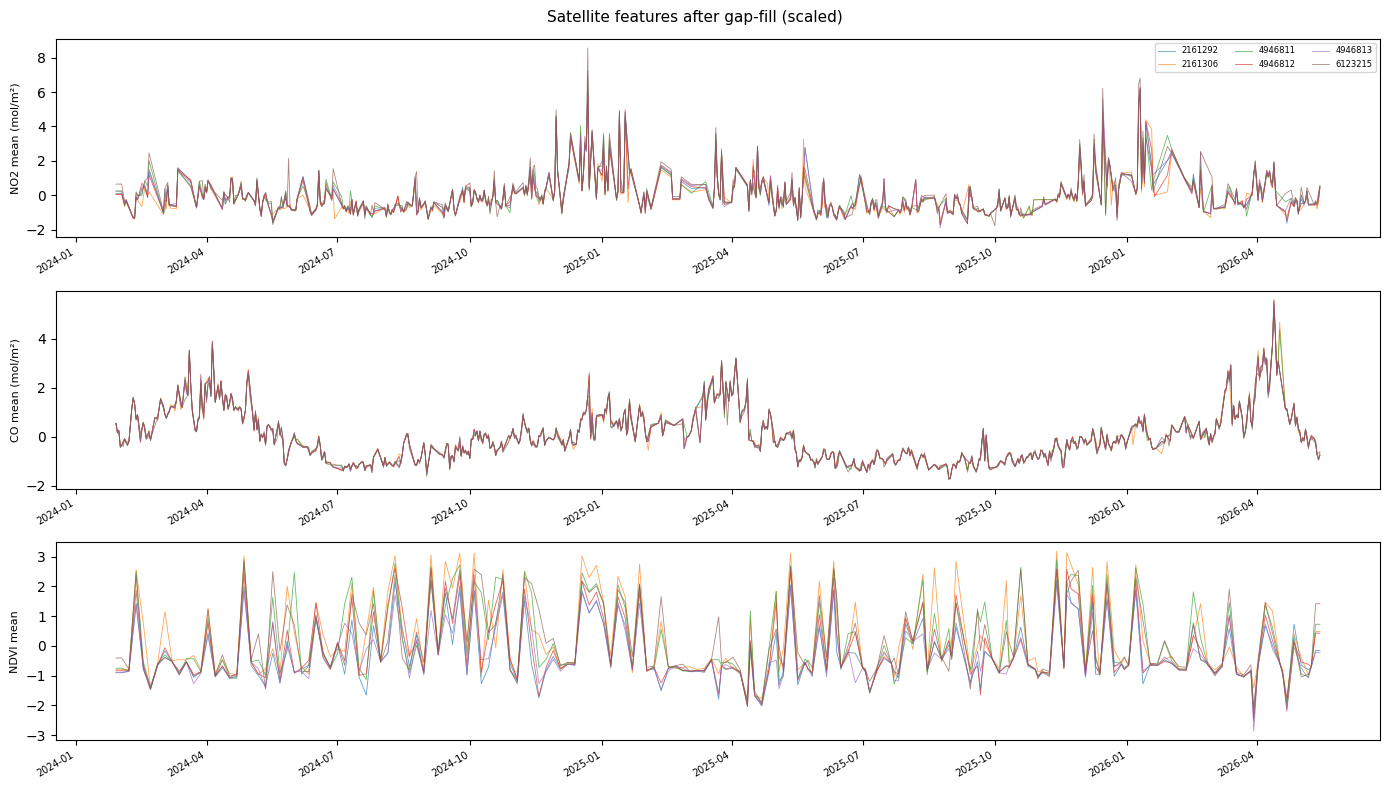

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
PLOT = [('no2_mean','NO2 mean (mol/m²)'),('co_mean','CO mean (mol/m²)'),('ndvi_mean','NDVI mean')]
for ax, (col, label) in zip(axes, PLOT):
    if col not in df_out.columns: continue
    for loc_id, grp in df_out.groupby('location_id'):
        grp = grp.sort_values('date')
        ax.plot(grp['date'], grp[col], lw=0.6, alpha=0.7, label=str(loc_id))
    ax.set_ylabel(label, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
axes[0].legend(fontsize=6, ncol=3)
plt.suptitle('Satellite features after gap-fill (scaled)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'satellite_overview.png', dpi=120, bbox_inches='tight')
plt.show()
